In [1]:
import kagglehub
path = kagglehub.dataset_download("balraj98/duts-saliency-detection-dataset")

Using Colab cache for faster access to the 'duts-saliency-detection-dataset' dataset.


In [2]:
import os
print(os.listdir(path))

['DUTS-TE', 'metadata.csv', 'DUTS-TR']


In [3]:
%cd Projekti3ML_DL/


/content/Projekti3ML_DL


In [5]:
import torch
import os
import importlib
from torch.utils.data import DataLoader, Subset
from sod_model import SODModel
import data_loader
from train import train_one_epoch, hybrid_loss
from evaluate import calculate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
img_dir = os.path.join(path, 'DUTS-TR', 'DUTS-TR-Image')
mask_dir = os.path.join(path, 'DUTS-TR', 'DUTS-TR-Mask')

train_dataset_full = data_loader.DUTSDataset(img_dir, mask_dir, is_train=True)
val_dataset_full = data_loader.DUTSDataset(img_dir, mask_dir, is_train=False)

num_data = len(train_dataset_full)
indices = list(range(num_data))
split = int(0.8 * num_data)

train_indices = indices[:split]
val_indices = indices[split:]

train_ds = Subset(train_dataset_full, train_indices)
val_ds = Subset(val_dataset_full, val_indices)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}")

Train size: 8442, Val size: 2111


In [7]:
model = SODModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
best_val_loss = float('inf')
model_save_path = 'best_sod_model.pth'

for epoch in range(15):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = hybrid_loss(preds, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_save_path)
        print(f"Model improved! Saved to {model_save_path} ---")

Epoch 1 | Train Loss: 0.8843 | Val Loss: 0.8459
Model improved! Saved to best_sod_model.pth ---
Epoch 2 | Train Loss: 0.8396 | Val Loss: 0.8558
Epoch 3 | Train Loss: 0.8289 | Val Loss: 0.8445
Model improved! Saved to best_sod_model.pth ---
Epoch 4 | Train Loss: 0.8205 | Val Loss: 0.9065
Epoch 5 | Train Loss: 0.8143 | Val Loss: 0.8754
Epoch 6 | Train Loss: 0.8120 | Val Loss: 0.8667
Epoch 7 | Train Loss: 0.8084 | Val Loss: 0.8580
Epoch 8 | Train Loss: 0.8049 | Val Loss: 0.8570
Epoch 9 | Train Loss: 0.8014 | Val Loss: 0.8603
Epoch 10 | Train Loss: 0.7986 | Val Loss: 0.8442
Model improved! Saved to best_sod_model.pth ---
Epoch 11 | Train Loss: 0.7968 | Val Loss: 0.8653
Epoch 12 | Train Loss: 0.7933 | Val Loss: 0.8977
Epoch 13 | Train Loss: 0.7925 | Val Loss: 0.8397
Model improved! Saved to best_sod_model.pth ---
Epoch 14 | Train Loss: 0.7928 | Val Loss: 0.9440
Epoch 15 | Train Loss: 0.7896 | Val Loss: 0.9184


In [9]:
import importlib
import evaluate
importlib.reload(evaluate)
from evaluate import calculate_metrics

In [14]:
import evaluate
importlib.reload(evaluate)

model.load_state_dict(torch.load('best_sod_model.pth'))
model.eval()

m_totals = {"prec": 0, "rec": 0, "f1": 0, "iou": 0}

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        p, r, f1, iou = evaluate.calculate_metrics(preds, masks, threshold=0.6)

        m_totals["prec"] += p
        m_totals["rec"] += r
        m_totals["f1"] += f1
        m_totals["iou"] += iou

n = len(val_loader)

print("--- Final Validation Metrics ---")
print(f"Precision: {m_totals['prec']/n:.4f}")
print(f"Recall:    {m_totals['rec']/n:.4f}")
print(f"F1 Score:  {m_totals['f1']/n:.4f}")
print(f"IoU:       {m_totals['iou']/n:.4f}")

--- Final Validation Metrics ---
Precision: 0.6942
Recall:    0.4212
F1 Score:  0.5059
IoU:       0.3655


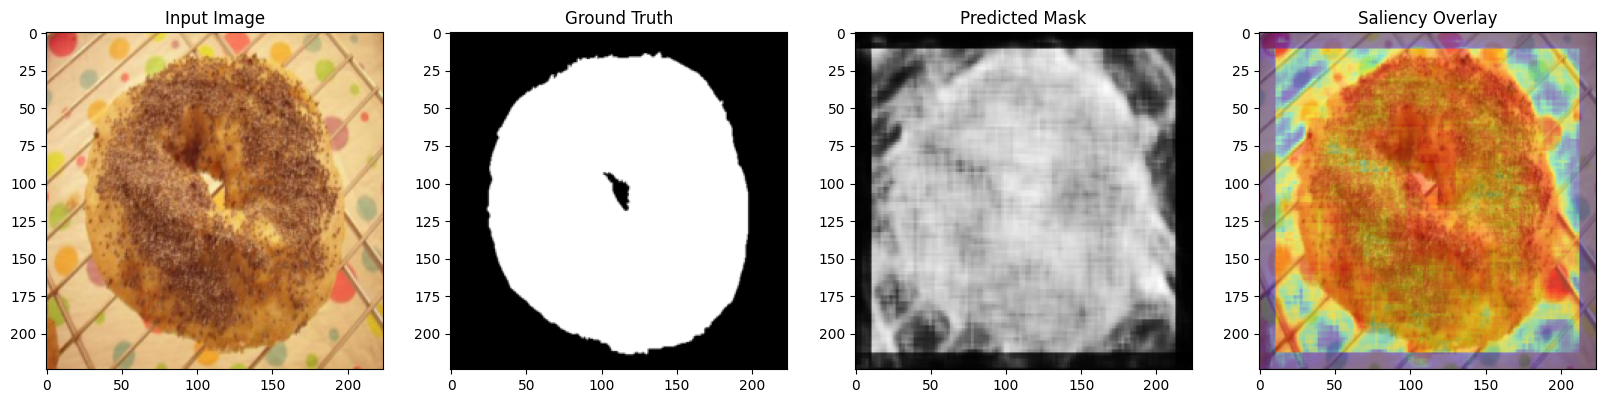

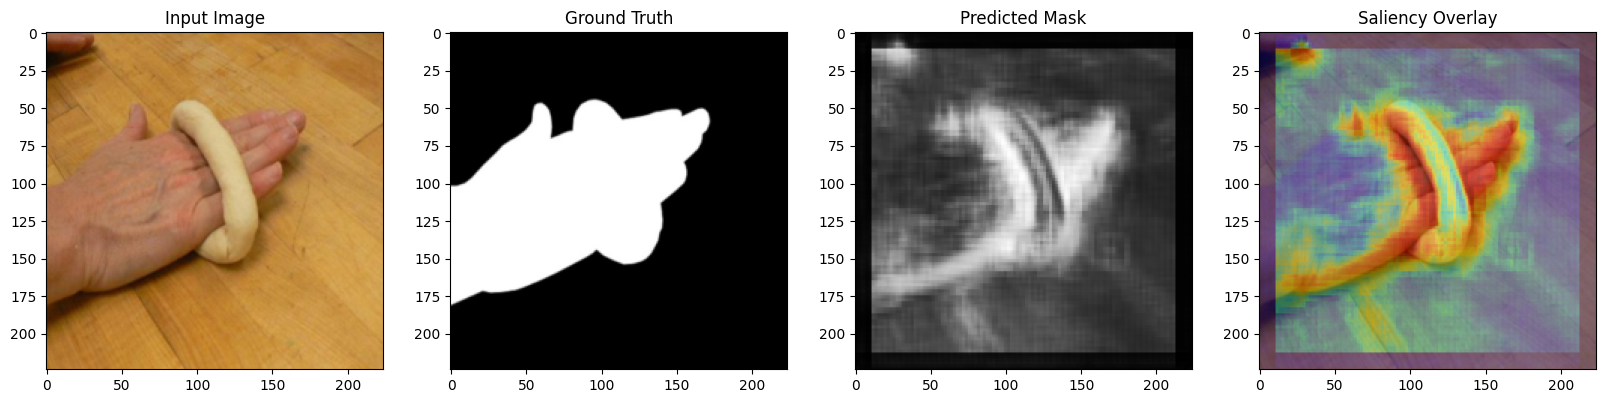

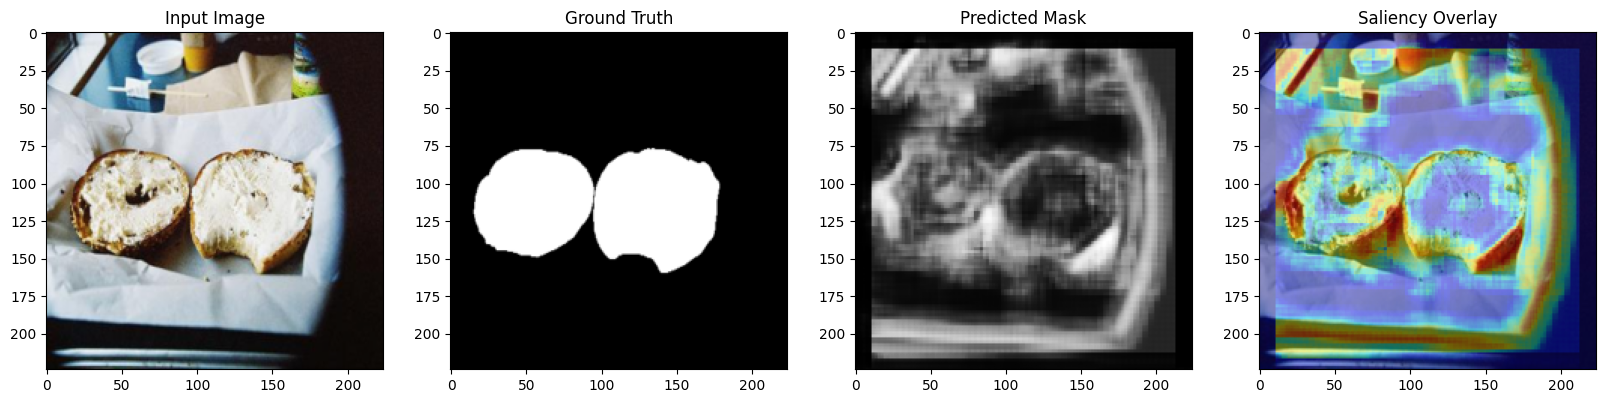

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_saliency(model, dataset, idx=0):
    model.eval()
    image, mask = dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(input_tensor).squeeze(0).cpu().numpy()[0]

    img_show = image.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(img_show); ax[0].set_title("Input Image")
    ax[1].imshow(mask.squeeze(), cmap='gray'); ax[1].set_title("Ground Truth")
    ax[2].imshow(prediction, cmap='gray'); ax[2].set_title("Predicted Mask")

    ax[3].imshow(img_show)
    ax[3].imshow(prediction, cmap='jet', alpha=0.4)
    ax[3].set_title("Saliency Overlay")
    plt.show()

for i in range(3):
    visualize_saliency(model, val_ds, idx=i)